# Web Mining AMAZON

In [ ]:
# =========================
# 1. Imports and setup
# =========================
import os
import re
import time
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [ ]:
# =========================
# 2. Paths and configuration
# =========================
# Update these paths if your files are stored elsewhere.

DATA_DIR = Path("/content/data")

AMAZON_TRAIN_PATH = DATA_DIR / "train_sub.csv"
AMAZON_TEST_PATH  = DATA_DIR / "test_sub.csv"
YELP_TEST_PATH = DATA_DIR / "test.csv"

TEXT_MAX_LEN = 200
MAX_VOCAB = 50_000
MIN_FREQ = 2
BATCH_SIZE = 256

TEXTCNN_CONFIG = {
    "emb_dim": 128,
    "num_filters": 128,
    "kernel_sizes": (3, 4, 5),
    "dropout": 0.5,
    "lr": 1e-3,
    "epochs": 10,
}

BILSTM_CONFIG = {
    "emb_dim": 128,
    "hidden_dim": 128,
    "dropout": 0.5,
    "lr": 1e-3,
    "epochs": 10,
}

BERT_MAX_LEN = 256
BERT_BATCH_SIZE_EVAL = 32

## Optional: mount Google Drive in Colab
Run the next cell only if your data is on Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%%bash
mkdir -p /content/data
unzip -q "/content/drive/MyDrive/Colab Notebooks/WebMining/amazon_reviews.zip" -d /content/data
unzip -q "/content/drive/MyDrive/Colab Notebooks/WebMining/yelp_reviews.zip" -d /content/data

In [ ]:
# =========================
# 3. Text preprocessing helpers
# =========================
URL_RE = re.compile(r"http\S+|www\.\S+")
HTML_RE = re.compile(r"<.*?>")
WS_RE = re.compile(r"\s+")

def preprocess_text(text: str) -> str:
    text = str(text).lower()
    text = URL_RE.sub(" ", text)
    text = HTML_RE.sub(" ", text)
    text = WS_RE.sub(" ", text).strip()
    return text

def simple_tokenize(text: str):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

def load_sentiment_csv(path: str | Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df.copy()
    df["label"] = df["label"].astype(int)
    df["text_clean"] = df["text"].map(preprocess_text)
    return df

def df_to_xy(df: pd.DataFrame):
    texts = df["text_clean"].astype(str).tolist()
    labels = df["label"].astype(int).values
    return texts, labels

In [ ]:
# =========================
# 4. Load datasets
# =========================
df_train_amz = load_sentiment_csv(AMAZON_TRAIN_PATH)
df_test_amz = load_sentiment_csv(AMAZON_TEST_PATH)
df_test_ylp = load_sentiment_csv(YELP_TEST_PATH)

X_train_text, y_train = df_to_xy(df_train_amz)
X_test_text, y_test = df_to_xy(df_test_amz)
X_test_amz_text, y_test_amz = df_to_xy(df_test_ylp)

print("Amazon train:", df_train_amz.shape)
print("Amazon test :", df_test_amz.shape)
print("Yelp test:", df_test_ylp.shape)

display(df_train_amz.head())

Amazon train: (560000, 4)
Amazon test : (38000, 4)
Yelp test: (38000, 3)


,Unnamed: 0,label,text,text_clean
0,0,1,forget the movies this one is a clasic worth r...,forget the movies this one is a clasic worth r...
1,1,1,"If you're a fan of THE INVISIBLES, you have to...","if you're a fan of the invisibles, you have to..."
2,2,1,I personly think that the camara angles aren't...,i personly think that the camara angles aren't...
3,3,0,I know that miners were a tough breed but I ca...,i know that miners were a tough breed but i ca...
4,4,1,This is a great book that blends accurate acco...,this is a great book that blends accurate acco...


## Shared vocabulary and classic DL datasets
The next section is used by **TextCNN** and **BiLSTM**.

In [ ]:
# =========================
# 5. Vocabulary and PyTorch datasets for TextCNN / BiLSTM
# =========================
def build_vocab(texts, max_vocab=50_000, min_freq=2, specials=("<pad>", "<unk>")):
    counter = Counter()
    for text in texts:
        counter.update(simple_tokenize(text))

    vocab = {token: idx for idx, token in enumerate(specials)}
    for word, freq in counter.most_common():
        if freq < min_freq:
            continue
        if word in vocab:
            continue
        vocab[word] = len(vocab)
        if len(vocab) >= max_vocab:
            break
    return vocab

def encode_text(text: str, vocab: dict, max_len: int):
    token_ids = [vocab.get(tok, vocab["<unk>"]) for tok in simple_tokenize(text)[:max_len]]
    if len(token_ids) < max_len:
        token_ids += [vocab["<pad>"]] * (max_len - len(token_ids))
    return token_ids

class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = torch.tensor(encode_text(self.texts[idx], self.vocab, self.max_len), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y

def build_text_dataloader(texts, labels, vocab, max_len, batch_size, shuffle=False):
    ds = TextDataset(texts, labels, vocab, max_len)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0)

vocab = build_vocab(X_train_text, max_vocab=MAX_VOCAB, min_freq=MIN_FREQ)
PAD_IDX = vocab["<pad>"]

train_loader = build_text_dataloader(
    X_train_text, y_train, vocab, TEXT_MAX_LEN, BATCH_SIZE, shuffle=True
)
test_loader = build_text_dataloader(
    X_test_text, y_test, vocab, TEXT_MAX_LEN, BATCH_SIZE, shuffle=False
)
amazon_loader = build_text_dataloader(
    X_test_amz_text, y_test_amz, vocab, TEXT_MAX_LEN, BATCH_SIZE, shuffle=False
)

print("Vocab size:", len(vocab))

Vocab size: 50000


In [ ]:
# =========================
# 6. Shared training / evaluation utilities
# =========================
def binary_metrics_from_probs(y_true, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, preds),
        "macro_f1": f1_score(y_true, preds, average="macro"),
        "preds": preds,
    }

def run_binary_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    all_probs, all_y = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        if train_mode:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)
        probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
        labels = y.detach().cpu().numpy().astype(int).reshape(-1)

        all_probs.append(probs)
        all_y.append(labels)

    avg_loss = total_loss / len(loader.dataset)
    all_probs = np.concatenate(all_probs)
    all_y = np.concatenate(all_y)

    metrics = binary_metrics_from_probs(all_y, all_probs)
    metrics["loss"] = avg_loss
    metrics["labels"] = all_y
    metrics["probs"] = all_probs
    return metrics

def train_binary_model(model, train_loader, test_loader, epochs, lr, device=DEVICE):
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "train_acc": [],
        "train_f1": [],
        "test_loss": [],
        "test_acc": [],
        "test_f1": [],
    }

    start = time.time()

    for epoch in range(1, epochs + 1):
        train_metrics = run_binary_epoch(model, train_loader, criterion, optimizer=optimizer, device=device)
        test_metrics = run_binary_epoch(model, test_loader, criterion, optimizer=None, device=device)

        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["accuracy"])
        history["train_f1"].append(train_metrics["macro_f1"])
        history["test_loss"].append(test_metrics["loss"])
        history["test_acc"].append(test_metrics["accuracy"])
        history["test_f1"].append(test_metrics["macro_f1"])

        print(
            f"Epoch {epoch:02d} | "
            f"train loss {train_metrics['loss']:.4f} acc {train_metrics['accuracy']:.4f} f1 {train_metrics['macro_f1']:.4f} | "
            f"test loss {test_metrics['loss']:.4f} acc {test_metrics['accuracy']:.4f} f1 {test_metrics['macro_f1']:.4f}"
        )

    elapsed = time.time() - start
    print(f"\nTotal training time: {elapsed:.2f}s")
    return model, history, elapsed

def evaluate_binary_model(model, loader, device=DEVICE, title=None):
    criterion = nn.BCEWithLogitsLoss()
    metrics = run_binary_epoch(model, loader, criterion, optimizer=None, device=device)

    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Macro F1: {metrics['macro_f1']:.4f}")
    print("\nClassification report:\n")
    print(classification_report(metrics["labels"], metrics["preds"], digits=4))

    if title is not None:
        plot_confusion_matrix(metrics["labels"], metrics["preds"], title=title)

    return metrics

def plot_history(history, model_name="Model"):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["test_loss"], label="Test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss Curves ({model_name})")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_acc"], label="Train accuracy")
    plt.plot(epochs, history["test_acc"], label="Test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy Curves ({model_name})")
    plt.legend()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix", labels=("Negative", "Positive")):
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        values_format="d",
        display_labels=list(labels)
    )
    plt.title(title)
    plt.show()

def save_torch_checkpoint(path, model, history=None, extra=None):
    payload = {"model_state": model.state_dict()}
    if history is not None:
        payload["history"] = history
    if extra is not None:
        payload["extra"] = extra
    torch.save(payload, path)
    print(f"Saved to: {path}")

# TextCNN

In [ ]:
# =========================
# 7. TextCNN definition
# =========================
class TextCNN(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, num_filters=128, kernel_sizes=(3, 4, 5), dropout=0.5, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=emb_dim, out_channels=num_filters, kernel_size=k)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), 1)

    def forward(self, x):
        emb = self.embedding(x)
        emb = emb.transpose(1, 2)

        pooled_features = []
        for conv in self.convs:
            conv_out = torch.relu(conv(emb))
            pooled = torch.max(conv_out, dim=2).values
            pooled_features.append(pooled)

        features = torch.cat(pooled_features, dim=1)
        features = self.dropout(features)
        logits = self.fc(features).squeeze(1)
        return logits

In [ ]:
# =========================
# 8. Train TextCNN
# =========================
textcnn = TextCNN(
    vocab_size=len(vocab),
    emb_dim=TEXTCNN_CONFIG["emb_dim"],
    num_filters=TEXTCNN_CONFIG["num_filters"],
    kernel_sizes=TEXTCNN_CONFIG["kernel_sizes"],
    dropout=TEXTCNN_CONFIG["dropout"],
    pad_idx=PAD_IDX,
)

textcnn, textcnn_history, textcnn_train_time = train_binary_model(
    model=textcnn,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=TEXTCNN_CONFIG["epochs"],
    lr=TEXTCNN_CONFIG["lr"],
    device=DEVICE,
)

Epoch 01 | train loss 0.3458 acc 0.8449 f1 0.8371 | test loss 0.2517 acc 0.8996 f1 0.8962
Epoch 02 | train loss 0.2430 acc 0.9012 f1 0.8966 | test loss 0.2246 acc 0.9116 f1 0.9079
Epoch 03 | train loss 0.2127 acc 0.9155 f1 0.9117 | test loss 0.2189 acc 0.9136 f1 0.9093
Epoch 04 | train loss 0.1923 acc 0.9250 f1 0.9217 | test loss 0.2169 acc 0.9157 f1 0.9119
Epoch 05 | train loss 0.1757 acc 0.9327 f1 0.9297 | test loss 0.2248 acc 0.9148 f1 0.9115
Epoch 06 | train loss 0.1612 acc 0.9391 f1 0.9364 | test loss 0.2280 acc 0.9155 f1 0.9117
Epoch 07 | train loss 0.1482 acc 0.9440 f1 0.9416 | test loss 0.2347 acc 0.9136 f1 0.9100
Epoch 08 | train loss 0.1372 acc 0.9490 f1 0.9468 | test loss 0.2467 acc 0.9133 f1 0.9097
Epoch 09 | train loss 0.1262 acc 0.9534 f1 0.9514 | test loss 0.2598 acc 0.9131 f1 0.9092
Epoch 10 | train loss 0.1175 acc 0.9567 f1 0.9548 | test loss 0.2721 acc 0.9106 f1 0.9064

Total training time: 1030.15s


Accuracy: 0.9106
Macro F1: 0.9064

Classification report:

              precision    recall  f1-score   support

           0     0.9003    0.8732    0.8866     15200
           1     0.9171    0.9355    0.9262     22800

    accuracy                         0.9106     38000
   macro avg     0.9087    0.9044    0.9064     38000
weighted avg     0.9104    0.9106    0.9104     38000



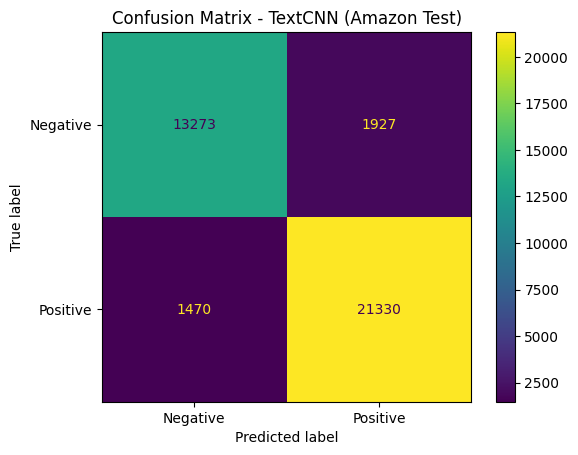

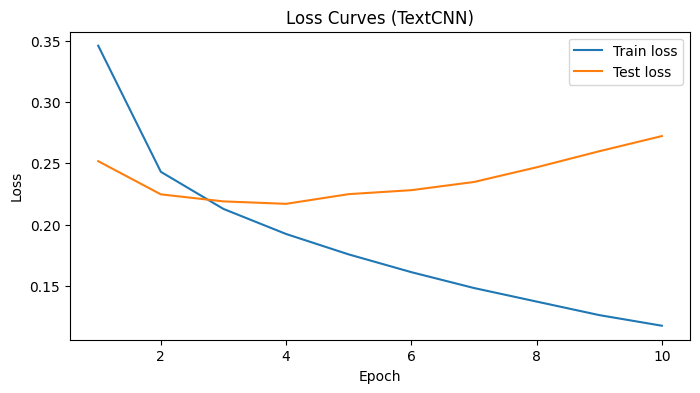

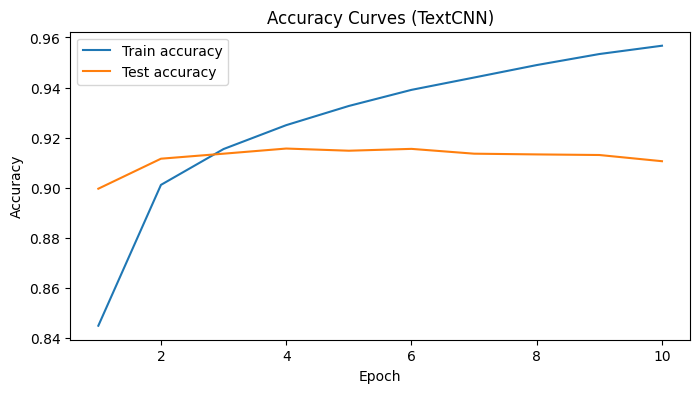

Saved to: textcnn_amazon.pt


In [ ]:
# Amazon test evaluation
textcnn_test_metrics = evaluate_binary_model(
    textcnn,
    test_loader,
    device=DEVICE,
    title="Confusion Matrix - TextCNN (Amazon Test)"
)

plot_history(textcnn_history, model_name="TextCNN")
save_torch_checkpoint("textcnn_amazon.pt", textcnn, history=textcnn_history)

# BiLSTM

In [ ]:
# =========================
# 9. BiLSTM definition
# =========================
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, pad_idx, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        emb = self.embedding(x)
        lstm_out, _ = self.lstm(emb)
        pooled = torch.max(lstm_out, dim=1).values
        pooled = self.dropout(pooled)
        logits = self.fc(pooled).squeeze(1)
        return logits

In [ ]:
# =========================
# 10. Train BiLSTM
# =========================
bilstm = BiLSTM(
    vocab_size=len(vocab),
    emb_dim=BILSTM_CONFIG["emb_dim"],
    hidden_dim=BILSTM_CONFIG["hidden_dim"],
    pad_idx=PAD_IDX,
    dropout=BILSTM_CONFIG["dropout"],
)

bilstm, bilstm_history, bilstm_train_time = train_binary_model(
    model=bilstm,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=BILSTM_CONFIG["epochs"],
    lr=BILSTM_CONFIG["lr"],
    device=DEVICE,
)

Epoch 01 | train loss 0.2954 acc 0.8721 f1 0.8657 | test loss 0.2230 acc 0.9111 f1 0.9067
Epoch 02 | train loss 0.1992 acc 0.9217 f1 0.9183 | test loss 0.1979 acc 0.9222 f1 0.9190
Epoch 03 | train loss 0.1702 acc 0.9352 f1 0.9324 | test loss 0.1967 acc 0.9235 f1 0.9208
Epoch 04 | train loss 0.1481 acc 0.9447 f1 0.9423 | test loss 0.1965 acc 0.9249 f1 0.9216
Epoch 05 | train loss 0.1281 acc 0.9531 f1 0.9511 | test loss 0.2084 acc 0.9238 f1 0.9211
Epoch 06 | train loss 0.1098 acc 0.9607 f1 0.9591 | test loss 0.2105 acc 0.9238 f1 0.9205
Epoch 07 | train loss 0.0949 acc 0.9670 f1 0.9656 | test loss 0.2240 acc 0.9232 f1 0.9200
Epoch 08 | train loss 0.0792 acc 0.9731 f1 0.9719 | test loss 0.2479 acc 0.9222 f1 0.9188
Epoch 09 | train loss 0.0698 acc 0.9766 f1 0.9756 | test loss 0.2720 acc 0.9210 f1 0.9177
Epoch 10 | train loss 0.0579 acc 0.9812 f1 0.9804 | test loss 0.2921 acc 0.9193 f1 0.9158

Total training time: 1380.75s


Accuracy: 0.9193
Macro F1: 0.9158

Classification report:

              precision    recall  f1-score   support

           0     0.9024    0.8951    0.8987     15200
           1     0.9304    0.9354    0.9329     22800

    accuracy                         0.9193     38000
   macro avg     0.9164    0.9153    0.9158     38000
weighted avg     0.9192    0.9193    0.9192     38000



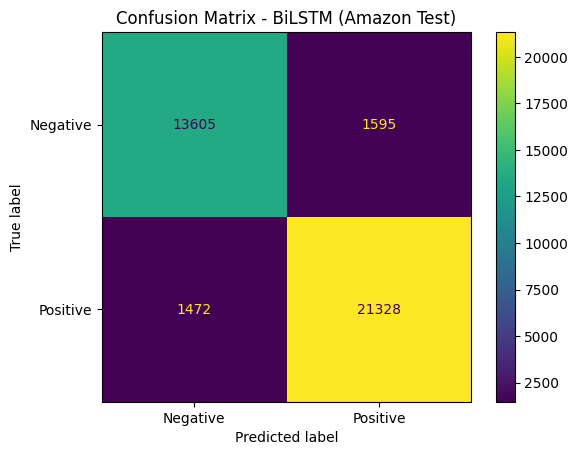

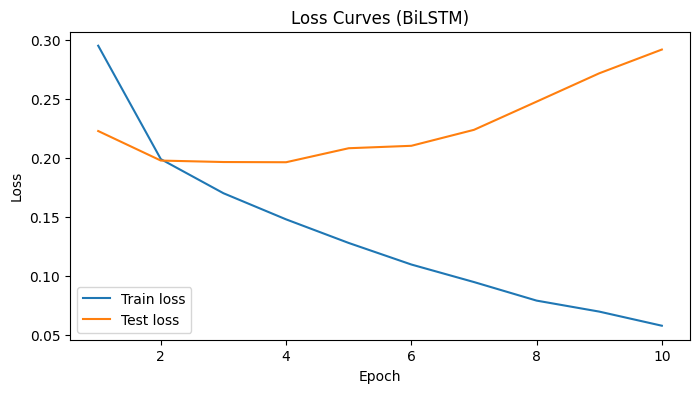

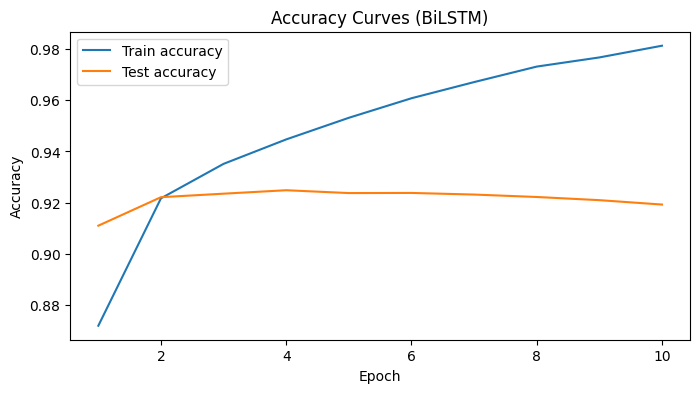

Saved to: bilstm_amazon.pt


In [ ]:
# Amazon test evaluation
bilstm_test_metrics = evaluate_binary_model(
    bilstm,
    test_loader,
    device=DEVICE,
    title="Confusion Matrix - BiLSTM (Amazon Test)"
)

plot_history(bilstm_history, model_name="BiLSTM")
save_torch_checkpoint("bilstm_amazon.pt", bilstm, history=bilstm_history)

# Transformer-based models (BERT / DistilBERT)

In [ ]:
# =========================
# 11. Install / import transformers
# =========================
# Uncomment in a fresh Colab runtime:
!pip -q install transformers datasets accelerate scikit-learn

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)

In [ ]:
# =========================
# 12. Hugging Face dataset helpers
# =========================
class SentimentDatasetHF(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)
        return item

def build_hf_dataset(df, tokenizer, max_len=BERT_MAX_LEN):
    return SentimentDatasetHF(
        texts=df["text_clean"].tolist(),
        labels=df["label"].tolist(),
        tokenizer=tokenizer,
        max_len=max_len
    )

def compute_hf_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

def evaluate_hf_model_manual(model, dataset, batch_size=32, device=DEVICE, title=None):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    model.eval()

    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].cpu().numpy()

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print("\nClassification report:\n")
    print(classification_report(all_labels, all_preds, digits=4))

    if title is not None:
        plot_confusion_matrix(all_labels, all_preds, title=title, labels=("negative", "positive"))

    return {
        "labels": all_labels,
        "preds": all_preds,
        "accuracy": acc,
        "macro_f1": macro_f1,
    }

## Pretrained BERT without fine-tuning

config.json:   0%|          | 0.00/477 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Accuracy: 0.8874
Macro F1: 0.8848

Classification report:

              precision    recall  f1-score   support

           0     0.8190    0.9223    0.8676     15200
           1     0.9434    0.8641    0.9020     22800

    accuracy                         0.8874     38000
   macro avg     0.8812    0.8932    0.8848     38000
weighted avg     0.8937    0.8874    0.8883     38000



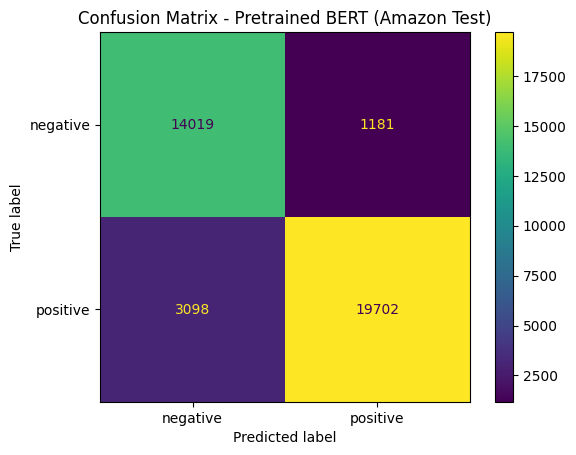

In [ ]:
# =========================
# 13. Evaluate pretrained BERT on Yelp test
# =========================
raw_model_name = "textattack/bert-base-uncased-SST-2"

raw_tokenizer = AutoTokenizer.from_pretrained(raw_model_name)
raw_model = AutoModelForSequenceClassification.from_pretrained(raw_model_name).to(DEVICE)

raw_amz_test_dataset = build_hf_dataset(df_test_amz, raw_tokenizer, max_len=BERT_MAX_LEN)

raw_amazon_metrics = evaluate_hf_model_manual(
    raw_model,
    raw_amz_test_dataset,
    batch_size=BERT_BATCH_SIZE_EVAL,
    device=DEVICE,
    title="Confusion Matrix - Pretrained BERT (Amazon Test)"
)

## Fine-tuned DistilBERT on Amazon

In [ ]:
# =========================
# 14. Fine-tune DistilBERT
# =========================
ft_model_name = "distilbert-base-uncased"

ft_tokenizer = AutoTokenizer.from_pretrained(ft_model_name)
ft_model = AutoModelForSequenceClassification.from_pretrained(ft_model_name, num_labels=2).to(DEVICE)

train_dataset_hf = build_hf_dataset(df_train_amz, ft_tokenizer, max_len=BERT_MAX_LEN)
test_dataset_hf = build_hf_dataset(df_test_amz, ft_tokenizer, max_len=BERT_MAX_LEN)

training_args = TrainingArguments(
    output_dir="./bert_sentiment_results",
    eval_strategy="epoch",
    save_strategy="no",
    logging_strategy="steps",
    logging_steps=1000,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    learning_rate=2e-5,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=train_dataset_hf,
    eval_dataset=test_dataset_hf,
    compute_metrics=compute_hf_metrics,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.131449,0.132671,0.953132,0.951071
2,0.093553,0.128359,0.956079,0.954237


TrainOutput(global_step=17500, training_loss=0.12610375409807478, metrics={'train_runtime': 7016.3387, 'train_samples_per_second': 159.627, 'train_steps_per_second': 2.494, 'total_flos': 7.418174324736e+16, 'train_loss': 0.12610375409807478, 'epoch': 2.0})

Trainer evaluate: {'eval_loss': 0.1283591389656067, 'eval_accuracy': 0.956078947368421, 'eval_macro_f1': 0.9542373450249424, 'eval_runtime': 104.559, 'eval_samples_per_second': 363.431, 'eval_steps_per_second': 11.362, 'epoch': 2.0}

Classification report:

              precision    recall  f1-score   support

           0     0.9458    0.9443    0.9451     15200
           1     0.9629    0.9639    0.9634     22800

    accuracy                         0.9561     38000
   macro avg     0.9544    0.9541    0.9542     38000
weighted avg     0.9561    0.9561    0.9561     38000



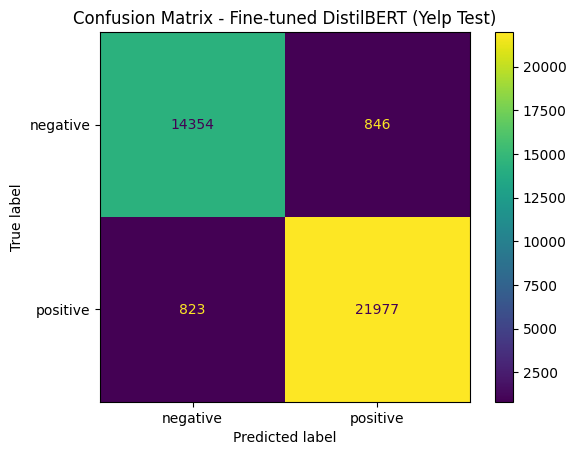

In [ ]:
# Amazon test evaluation for fine-tuned DistilBERT
ft_eval_results = trainer.evaluate()
print("Trainer evaluate:", ft_eval_results)

pred_output = trainer.predict(test_dataset_hf)
ft_logits = pred_output.predictions
ft_labels = pred_output.label_ids
ft_preds = np.argmax(ft_logits, axis=1)

print("\nClassification report:\n")
print(classification_report(ft_labels, ft_preds, digits=4))
plot_confusion_matrix(ft_labels, ft_preds, title="Confusion Matrix - Fine-tuned DistilBERT (Yelp Test)", labels=("negative", "positive"))

In [ ]:
# Save fine-tuned model
FT_SAVE_PATH = "./bert_finetuned"
trainer.save_model(FT_SAVE_PATH)
ft_tokenizer.save_pretrained(FT_SAVE_PATH)
print("Saved fine-tuned model to:", FT_SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved fine-tuned model to: ./bert_finetuned


In [ ]:
import shutil
from google.colab import files

shutil.make_archive("bert_finetuned_amz", "zip", "./bert_finetuned")
files.download("./bert_finetuned_amz.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
shutil.make_archive("bert_sentiment_results", "zip", "./bert_sentiment_results")
files.download("./bert_sentiment_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Cross-domain evaluation: Amazon → Yelp

=== TextCNN: Amazon -> Yelp ===
Accuracy: 0.8721
Macro F1: 0.8715

Classification report:

              precision    recall  f1-score   support

           0     0.9334    0.8014    0.8624     19000
           1     0.8260    0.9428    0.8806     19000

    accuracy                         0.8721     38000
   macro avg     0.8797    0.8721    0.8715     38000
weighted avg     0.8797    0.8721    0.8715     38000



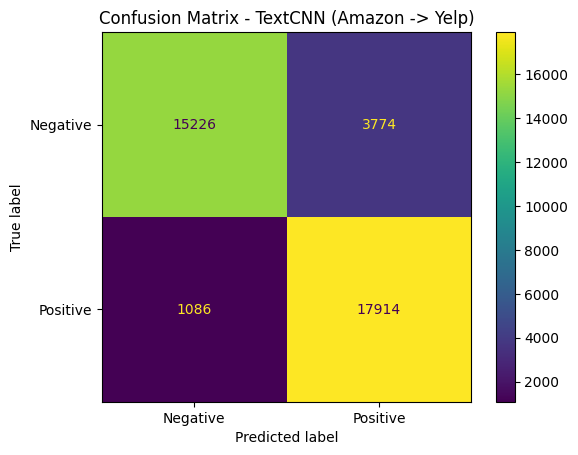


=== BiLSTM: Amazon -> Yelp ===
Accuracy: 0.8876
Macro F1: 0.8874

Classification report:

              precision    recall  f1-score   support

           0     0.9259    0.8427    0.8823     19000
           1     0.8557    0.9325    0.8924     19000

    accuracy                         0.8876     38000
   macro avg     0.8908    0.8876    0.8874     38000
weighted avg     0.8908    0.8876    0.8874     38000



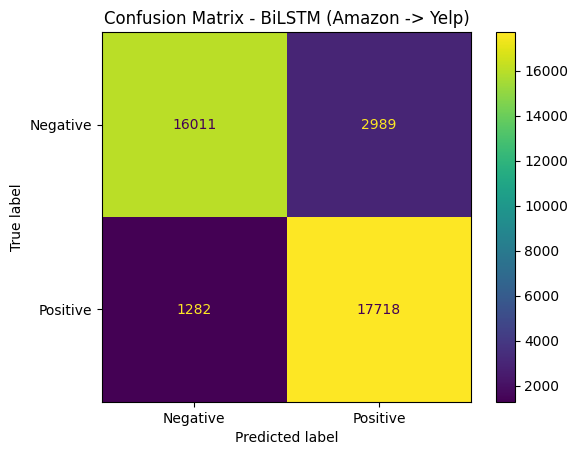

In [ ]:
# =========================
# 15. Cross-domain evaluation for TextCNN and BiLSTM
# =========================
print("=== TextCNN: Amazon -> Yelp ===")
textcnn_amz_metrics = evaluate_binary_model(
    textcnn,
    amazon_loader,
    device=DEVICE,
    title="Confusion Matrix - TextCNN (Amazon -> Yelp)"
)

print("\n=== BiLSTM: Amazon -> Yelp ===")
bilstm_amz_metrics = evaluate_binary_model(
    bilstm,
    amazon_loader,
    device=DEVICE,
    title="Confusion Matrix - BiLSTM (Amazon -> Yelp)"
)

=== Fine-tuned DistilBERT: Amazon -> Yelp ===
Accuracy: 0.9352105263157895
Macro F1: 0.9351066970310391

Classification report:

              precision    recall  f1-score   support

           0     0.9731    0.8952    0.9325     19000
           1     0.9030    0.9752    0.9377     19000

    accuracy                         0.9352     38000
   macro avg     0.9380    0.9352    0.9351     38000
weighted avg     0.9380    0.9352    0.9351     38000



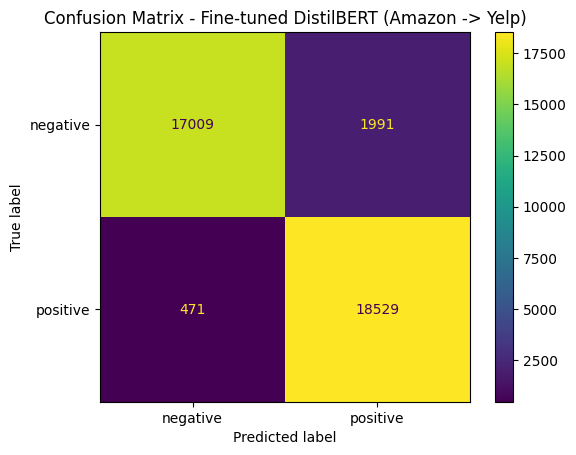

In [ ]:
# =========================
# 16. Cross-domain evaluation for fine-tuned DistilBERT
# =========================
amazon_dataset_hf = build_hf_dataset(df_test_ylp, ft_tokenizer, max_len=BERT_MAX_LEN)

amz_pred_output = trainer.predict(amazon_dataset_hf)
amz_logits = amz_pred_output.predictions
amz_labels = amz_pred_output.label_ids
amz_preds = np.argmax(amz_logits, axis=1)

print("=== Fine-tuned DistilBERT: Amazon -> Yelp ===")
print("Accuracy:", accuracy_score(amz_labels, amz_preds))
print("Macro F1:", f1_score(amz_labels, amz_preds, average="macro"))
print("\nClassification report:\n")
print(classification_report(amz_labels, amz_preds, digits=4))

plot_confusion_matrix(amz_labels, amz_preds, title="Confusion Matrix - Fine-tuned DistilBERT (Amazon -> Yelp)", labels=("negative", "positive"))

# Optional summary table
Use this section after all models finish running.

In [ ]:
# =========================
# 17. Collect results in one table
# =========================
summary_rows = [
    {
        "model": "TextCNN",
        "domain": "Amazon test",
        "accuracy": textcnn_test_metrics["accuracy"],
        "macro_f1": textcnn_test_metrics["macro_f1"],
    },
    {
        "model": "BiLSTM",
        "domain": "Amazon test",
        "accuracy": bilstm_test_metrics["accuracy"],
        "macro_f1": bilstm_test_metrics["macro_f1"],
    },
    {
        "model": "Pretrained BERT",
        "domain": "Amazon test",
        "accuracy": raw_amazon_metrics["accuracy"],
        "macro_f1": raw_amazon_metrics["macro_f1"],
    },
    {
        "model": "Fine-tuned DistilBERT",
        "domain": "Amazon test",
        "accuracy": accuracy_score(ft_labels, ft_preds),
        "macro_f1": f1_score(ft_labels, ft_preds, average="macro"),
    },
    {
        "model": "TextCNN",
        "domain": "Amazon -> Yelp",
        "accuracy": textcnn_amz_metrics["accuracy"],
        "macro_f1": textcnn_amz_metrics["macro_f1"],
    },
    {
        "model": "BiLSTM",
        "domain": "Amazon -> Yelp",
        "accuracy": bilstm_amz_metrics["accuracy"],
        "macro_f1": bilstm_amz_metrics["macro_f1"],
    },
    {
        "model": "Fine-tuned DistilBERT",
        "domain": "Amazon -> Yelp",
        "accuracy": accuracy_score(amz_labels, amz_preds),
        "macro_f1": f1_score(amz_labels, amz_preds, average="macro"),
    },
]

results_df = pd.DataFrame(summary_rows)
display(results_df.sort_values(["domain", "macro_f1"], ascending=[True, False]).reset_index(drop=True))

,model,domain,accuracy,macro_f1
0,Fine-tuned DistilBERT,Amazon -> Yelp,0.935211,0.935107
1,BiLSTM,Amazon -> Yelp,0.887605,0.887378
2,TextCNN,Amazon -> Yelp,0.872105,0.871462
3,Fine-tuned DistilBERT,Amazon test,0.956079,0.954237
4,BiLSTM,Amazon test,0.919289,0.915812
5,TextCNN,Amazon test,0.910605,0.906397
6,Pretrained BERT,Amazon test,0.887395,0.884819
